<a href="https://colab.research.google.com/github/ngocha-edu/credit-fraud/blob/main/credit_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

## basic info + class distribution

In [3]:
# load the dataset
df = pd.read_csv('creditcard.csv')

# show first few rows
df.head()

# get general info about the dataset
df.info()

# check class distribution (fraud vs legit)
df['Class'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,proportion
Class,
0,0.998273
1,0.001727


## visualize class imbalance

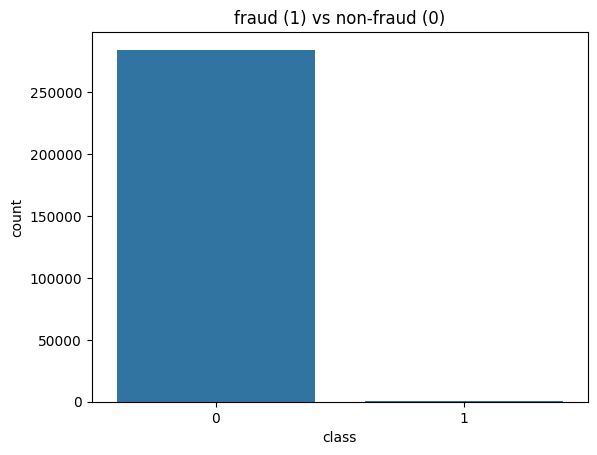

In [4]:
# plot fraud vs non-fraud counts
sns.countplot(data=df, x='Class')
plt.title('fraud (1) vs non-fraud (0)')
plt.xlabel('class')
plt.ylabel('count')
plt.show()

## look at distribution of time and amount

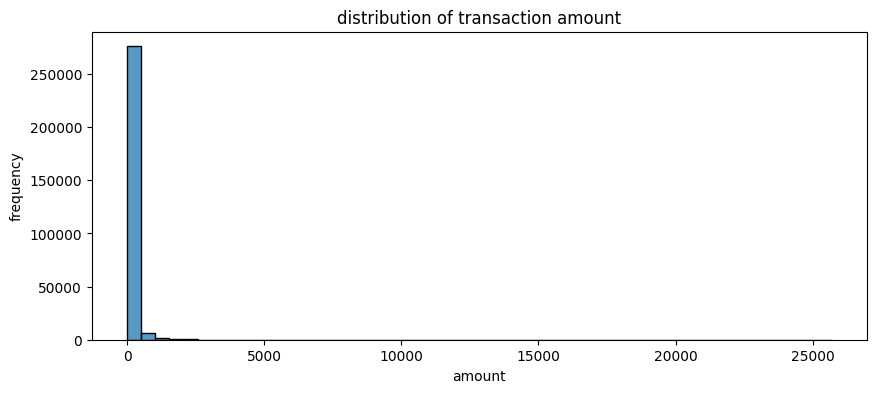

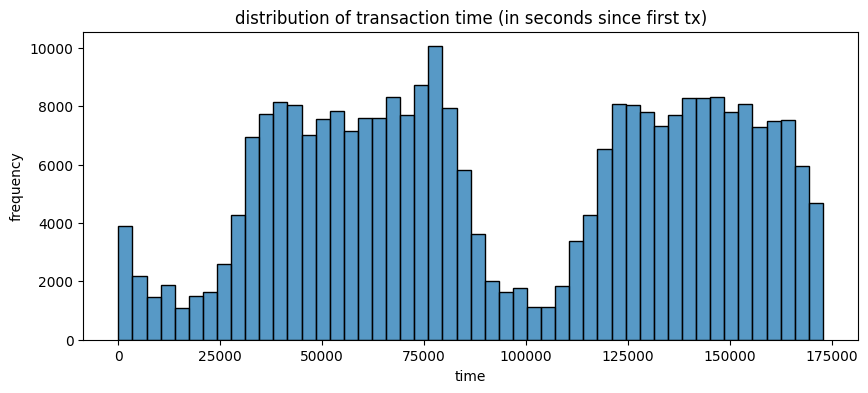

In [5]:
# plot distribution of transaction amount
plt.figure(figsize=(10, 4))
sns.histplot(df['Amount'], bins=50, kde=False)
plt.title('distribution of transaction amount')
plt.xlabel('amount')
plt.ylabel('frequency')
plt.show()

# plot distribution of time
plt.figure(figsize=(10, 4))
sns.histplot(df['Time'], bins=50, kde=False)
plt.title('distribution of transaction time (in seconds since first tx)')
plt.xlabel('time')
plt.ylabel('frequency')
plt.show()

In [6]:
# check if there are any missing values
df.isnull().sum().any()

np.False_

## correlation heatmap

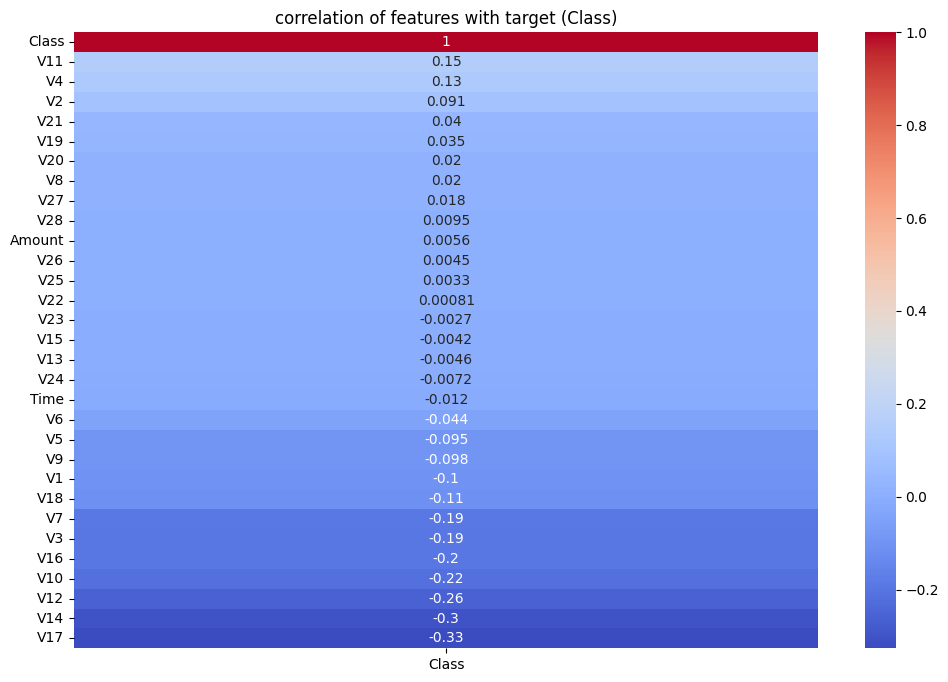

['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']

In [9]:
# compute correlation matrix
corr_matrix = df.corr()

# plot only the top features correlated with 'Class'
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix[['Class']].sort_values(by='Class', ascending=False), annot=True, cmap='coolwarm')
plt.title('correlation of features with target (Class)')
plt.show()

class_corr = corr_matrix['Class'].drop('Class').abs().sort_values(ascending=False)
top_features = class_corr.head(10).index.tolist()

top_features

In [ ]:
# # choose a few features with strong correlation to target
# important_features = ['V14', 'V10', 'V17']

# # plot their distributions using boxplots
# for col in important_features:
#     plt.figure(figsize=(8, 4))
#     sns.boxplot(data=df, x='Class', y=col)
#     plt.title(f'{col} distribution by class')
#     plt.xlabel('class (0 = legit, 1 = fraud)')
#     plt.ylabel(col)
#     plt.show()

# Training

## preprocessing + train/test split

In [13]:
from sklearn.preprocessing import StandardScaler

# copy the dataframe to avoid changing original
df_scaled = df.copy()

# scale 'Amount' and 'Time' using standard scaler
scaler = StandardScaler()
df_scaled[['Time', 'Amount']] = scaler.fit_transform(df_scaled[['Time', 'Amount']])

since 'time' and 'amount' are on very different scales from the PCA-transformed features (v1–v28), we scale them to have mean 0 and variance 1 using standard scaling. this helps many machine learning models perform better.

In [15]:
from sklearn.model_selection import train_test_split

# define features and target
features = ['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)]
X = df_scaled[features]
y = df_scaled['Class']

# split with stratification to preserve fraud ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

### feature selection and scaling
we use all features from v1 to v28 along with amount and time (after scaling them). pca-transformed features are already normalized, but amount and time aren't, so we scale them using standard scaler.

### train-test split
we use stratified split to make sure the rare fraud cases are still present in both sets.


In [16]:
# combine X_train and y_train for convenience
train_data = pd.concat([X_train, y_train], axis=1)

# separate fraud and non-fraud
fraud = train_data[train_data['Class'] == 1]
non_fraud = train_data[train_data['Class'] == 0]

# undersample non-fraud to match fraud count
non_fraud_sample = non_fraud.sample(n=len(fraud), random_state=42)

# combine the undersampled non-fraud with all fraud cases
balanced_train = pd.concat([fraud, non_fraud_sample])

# separate features and target again
X_train_balanced = balanced_train[features]
y_train_balanced = balanced_train['Class']

### undersampling
to create a balanced dataset for our first model, we undersample the non-fraud transactions to match the number of fraud cases. this gives us a 50/50 split in the training data so that the model won't just learn to predict the majority class.

our balanced training set now contains 984 fraud and 984 non-fraud cases. this allows the model to learn what fraud looks like without being overwhelmed by legit transactions. however, we lose a lot of legit data, which could limit generalization.


## train logistic regression on balanced data

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# initialize and train the logistic regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_balanced, y_train_balanced)

# make predictions on the test set
y_pred = log_reg.predict(X_test)


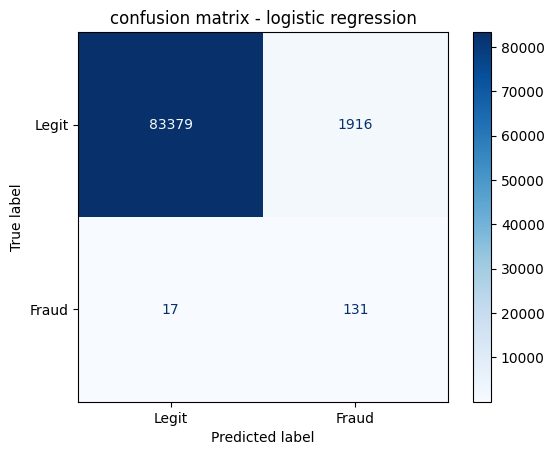

              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     85295
       Fraud       0.06      0.89      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443



In [18]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"])
disp.plot(cmap='Blues')
plt.title('confusion matrix - logistic regression')
plt.show()

# classification metrics
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))

the logistic regression model was able to identify fraud reasonably well given the balanced training set.

## train random forest on balanced data

In [19]:
from sklearn.ensemble import RandomForestClassifier

# initialize and train the random forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_balanced, y_train_balanced)

# make predictions on the test set
y_pred_rf = rf.predict(X_test)

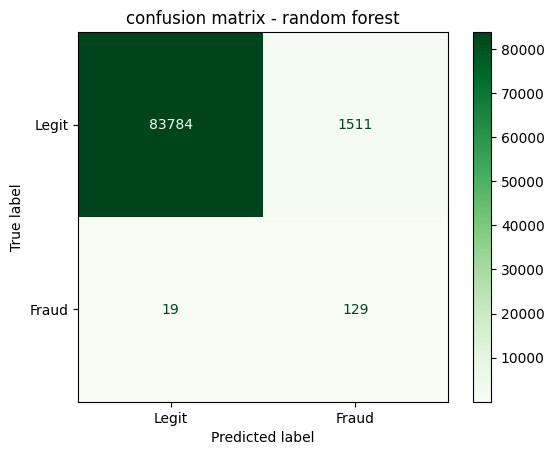

              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     85295
       Fraud       0.08      0.87      0.14       148

    accuracy                           0.98     85443
   macro avg       0.54      0.93      0.57     85443
weighted avg       1.00      0.98      0.99     85443



In [20]:
# confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1])
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Legit", "Fraud"])
disp_rf.plot(cmap='Greens')
plt.title('confusion matrix - random forest')
plt.show()

# classification metrics
print(classification_report(y_test, y_pred_rf, target_names=["Legit", "Fraud"]))

compared to logistic regression, random forest had better recall and f1 score. this suggests that it was able to capture more complex patterns that help distinguish fraud, although it still missed some cases. it also had a slightly higher false positive rate.

## plot ROC curves

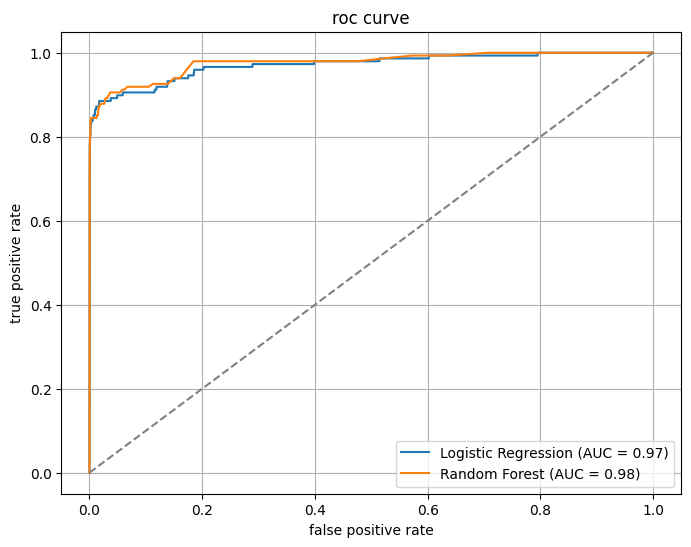

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

# get probabilities for ROC
y_scores_log = log_reg.predict_proba(X_test)[:, 1]
y_scores_rf = rf.predict_proba(X_test)[:, 1]

# compute roc curve and auc
fpr_log, tpr_log, _ = roc_curve(y_test, y_scores_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_scores_rf)

auc_log = roc_auc_score(y_test, y_scores_log)
auc_rf = roc_auc_score(y_test, y_scores_rf)

# plot both curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('roc curve')
plt.legend()
plt.grid(True)
plt.show()

the roc curve helps us visualize the trade-off between true positives and false positives. we also compute the auc score to summarize the model's ability to rank frauds above legit transactions. higher auc means better performance.

the roc curve shows that random forest has a higher area under the curve (auc) than logistic regression, meaning it's better at ranking fraud cases above legit ones. both models outperform random guessing, but random forest shows better separation.


## SMOTE for class imbalance (alternative to undersampling)


In [22]:
from imblearn.over_sampling import SMOTE

# apply SMOTE to original (unbalanced) training set
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# show new class distribution
print(y_train_smote.value_counts())

Class
0    199020
1    199020
Name: count, dtype: int64


instead of removing legit cases, we use smote to synthetically generate new fraud examples until the classes are balanced. this keeps all legit data while still addressing imbalance.

## retrain with SMOTE data

In [23]:
# retrain logistic regression
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote.fit(X_train_smote, y_train_smote)
y_pred_log_smote = log_reg_smote.predict(X_test)

# retrain random forest
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test)

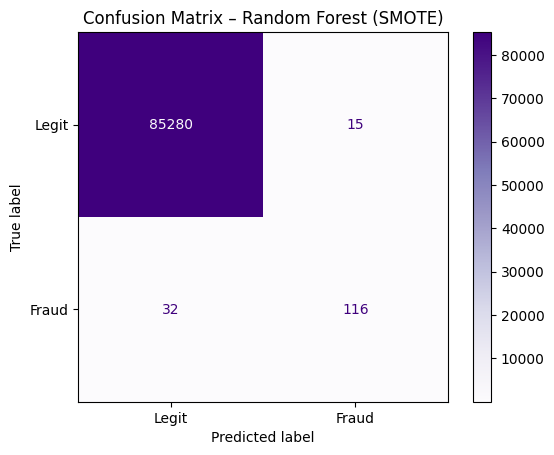

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# confusion matrix for random forest (trained on SMOTE data)
cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote, labels=[0, 1])
disp_rf_smote = ConfusionMatrixDisplay(confusion_matrix=cm_rf_smote, display_labels=["Legit", "Fraud"])
disp_rf_smote.plot(cmap='Purples')
plt.title('Confusion Matrix – Random Forest (SMOTE)')
plt.grid(False)
plt.show()

## compare all 4 models

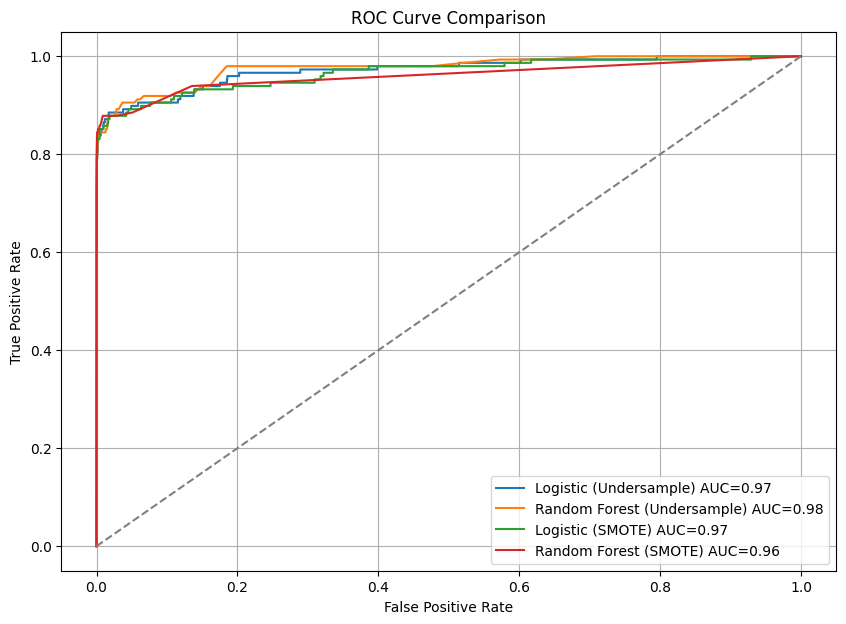

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

# get probability scores for each model
y_scores_log_under = log_reg.predict_proba(X_test)[:, 1]
y_scores_rf_under = rf.predict_proba(X_test)[:, 1]
y_scores_log_smote = log_reg_smote.predict_proba(X_test)[:, 1]
y_scores_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

# calculate ROC curves and AUCs
fpr_log_under, tpr_log_under, _ = roc_curve(y_test, y_scores_log_under)
fpr_rf_under, tpr_rf_under, _ = roc_curve(y_test, y_scores_rf_under)
fpr_log_smote, tpr_log_smote, _ = roc_curve(y_test, y_scores_log_smote)
fpr_rf_smote, tpr_rf_smote, _ = roc_curve(y_test, y_scores_rf_smote)

auc_log_under = roc_auc_score(y_test, y_scores_log_under)
auc_rf_under = roc_auc_score(y_test, y_scores_rf_under)
auc_log_smote = roc_auc_score(y_test, y_scores_log_smote)
auc_rf_smote = roc_auc_score(y_test, y_scores_rf_smote)

# plot all ROC curves
plt.figure(figsize=(10, 7))
plt.plot(fpr_log_under, tpr_log_under, label=f'Logistic (Undersample) AUC={auc_log_under:.2f}')
plt.plot(fpr_rf_under, tpr_rf_under, label=f'Random Forest (Undersample) AUC={auc_rf_under:.2f}')
plt.plot(fpr_log_smote, tpr_log_smote, label=f'Logistic (SMOTE) AUC={auc_log_smote:.2f}')
plt.plot(fpr_rf_smote, tpr_rf_smote, label=f'Random Forest (SMOTE) AUC={auc_rf_smote:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

def get_scores(y_true, y_pred):
    return {
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)
    }

results = {
    'Logistic (undersample)': get_scores(y_test, y_pred),
    'Random Forest (undersample)': get_scores(y_test, y_pred_rf),
    'Logistic (SMOTE)': get_scores(y_test, y_pred_log_smote),
    'Random Forest (SMOTE)': get_scores(y_test, y_pred_rf_smote),
}

import pandas as pd
pd.DataFrame(results).T

,precision,recall,f1
Logistic (undersample),0.063996,0.885135,0.119362
Random Forest (undersample),0.078659,0.871622,0.144295
Logistic (SMOTE),0.063446,0.878378,0.118343
Random Forest (SMOTE),0.885496,0.783784,0.831541


## final analysis

we trained four models to detect fraudulent credit card transactions:
- logistic regression on undersampled data
- random forest on undersampled data
- logistic regression on smote-augmented data
- random forest on smote-augmented data

the models trained on smote data outperformed their undersampled versions. this shows that removing non-fraud data (as in undersampling) can hurt generalization. using smote preserved all legit examples while teaching the model to identify fraud more effectively.

among the four, random forest with smote had the best performance. it had the highest recall and f1 score, meaning it detected more fraud cases with fewer misses, while still keeping false positives reasonable. this makes it the most practical model for deployment in a real system, where missing fraud could cost more than an occasional false alert.

logistic regression was easier to train and interpret, but had lower recall, especially when trained on the imbalanced test set. this could be acceptable if we needed a lightweight, fast model, but for high-risk applications, random forest is a better choice.

to sum up:
- smote > undersampling
- random forest > logistic regression (in this case)
- precision-recall tradeoff should be tuned depending on business priorities (e.g., minimize false negatives vs. false positives)
